# Cross-validation score

In [3]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [4]:
heart_disease = pd.read_csv("./data/heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
X = heart_disease.drop("target", axis=1)

In [6]:
y = heart_disease["target"]

In [7]:
X.head(), y.tail()

(   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal
 0   63    1   3       145   233    1        0      150      0      2.3      0   0     1
 1   37    1   2       130   250    0        1      187      0      3.5      0   0     2
 2   41    0   1       130   204    0        0      172      0      1.4      2   0     2
 3   56    1   1       120   236    0        1      178      0      0.8      2   0     2
 4   57    0   0       120   354    0        1      163      1      0.6      2   0     2,
 298    0
 299    0
 300    0
 301    0
 302    0
 Name: target, dtype: int64)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(clf, X, y, cv=5)
score

array([0.81967213, 0.8852459 , 0.83606557, 0.85      , 0.8       ])

In [10]:
mean_accuracy = np.mean(score)
mean_accuracy

np.float64(0.8381967213114756)

In [11]:
print(f"Heart disease classifier cross-validated accuracy: {(np.mean(score)*100):.2f} %")

Heart disease classifier cross-validated accuracy: 83.82 %


# Area under the receiver operating characteristic curve (AUC or ROC) 
* `AUC (Area under curve)`
* `ROC (Receiver operating characteristic curve)`
  
True positive rate vs false positive rate

In [12]:
y_probs = clf.predict_proba(X_test)
y_probs[:], len(y_probs)

(array([[0.95, 0.05],
        [0.38, 0.62],
        [0.45, 0.55],
        [0.86, 0.14],
        [0.21, 0.79],
        [0.16, 0.84],
        [0.36, 0.64],
        [0.95, 0.05],
        [0.96, 0.04],
        [0.53, 0.47],
        [0.19, 0.81],
        [0.64, 0.36],
        [0.07, 0.93],
        [0.87, 0.13],
        [0.04, 0.96],
        [0.03, 0.97],
        [0.01, 0.99],
        [0.92, 0.08],
        [0.98, 0.02],
        [0.94, 0.06],
        [0.54, 0.46],
        [0.9 , 0.1 ],
        [0.35, 0.65],
        [0.23, 0.77],
        [0.35, 0.65],
        [0.34, 0.66],
        [0.21, 0.79],
        [0.3 , 0.7 ],
        [0.9 , 0.1 ],
        [0.12, 0.88],
        [0.91, 0.09],
        [0.91, 0.09],
        [0.97, 0.03],
        [0.67, 0.33],
        [0.47, 0.53],
        [0.81, 0.19],
        [0.41, 0.59],
        [0.22, 0.78],
        [0.41, 0.59],
        [0.13, 0.87],
        [0.19, 0.81],
        [0.26, 0.74],
        [0.16, 0.84],
        [0.34, 0.66],
        [0.29, 0.71],
        [0

In [13]:
clf.score(X_test, y_test)

0.8360655737704918

In [14]:
y_probs_positive = y_probs[:, 1]
y_probs_positive[:10]

array([0.05, 0.62, 0.55, 0.14, 0.79, 0.84, 0.64, 0.05, 0.04, 0.47])

In [15]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)
fpr, tpr, thresholds

(array([0.        , 0.        , 0.        , 0.        , 0.03448276,
        0.03448276, 0.06896552, 0.10344828, 0.10344828, 0.13793103,
        0.13793103, 0.17241379, 0.17241379, 0.20689655, 0.20689655,
        0.24137931, 0.24137931, 0.31034483, 0.4137931 , 0.44827586,
        0.51724138, 0.55172414, 0.65517241, 0.68965517, 0.72413793,
        0.86206897, 1.        ]),
 array([0.     , 0.0625 , 0.28125, 0.40625, 0.4375 , 0.59375, 0.65625,
        0.6875 , 0.71875, 0.71875, 0.78125, 0.8125 , 0.90625, 0.90625,
        0.9375 , 0.9375 , 0.96875, 0.96875, 0.96875, 0.96875, 0.96875,
        0.96875, 0.96875, 1.     , 1.     , 1.     , 1.     ]),
 array([ inf, 0.99, 0.85, 0.81, 0.79, 0.7 , 0.66, 0.65, 0.64, 0.62, 0.59,
        0.55, 0.46, 0.41, 0.36, 0.35, 0.33, 0.24, 0.19, 0.16, 0.14, 0.13,
        0.1 , 0.09, 0.08, 0.05, 0.  ]))

In [16]:
from sklearn.metrics import roc_auc_score

In [17]:
roc_auc_score(y_test, y_probs_positive)

np.float64(0.9202586206896551)

# Create a function for plotting ROC curves

In [18]:
def plot_roc_curve(fpr, tpr):
    """
    Plots a ROC curve given the false positive rate (fpr)
    and true positive rate (tpr) of a model.
    """
    plt.plot(fpr, tpr, color = "red", label = "ROC")
    plt.plot([0,1], [0,1], color = "#000000", label = "Guessing", linestyle = "--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("Receiver operating characteristic curve")
    plt.legend()
    plt.show()    

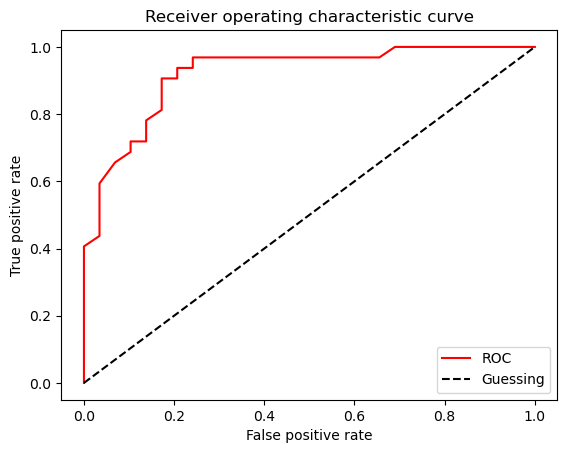

In [19]:
plot_roc_curve(fpr, tpr)

# Perfect ROC Curve

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_test)

In [21]:
fpr, tpr, thresholds

(array([0., 0., 1.]), array([0., 1., 1.]), array([inf,  1.,  0.]))

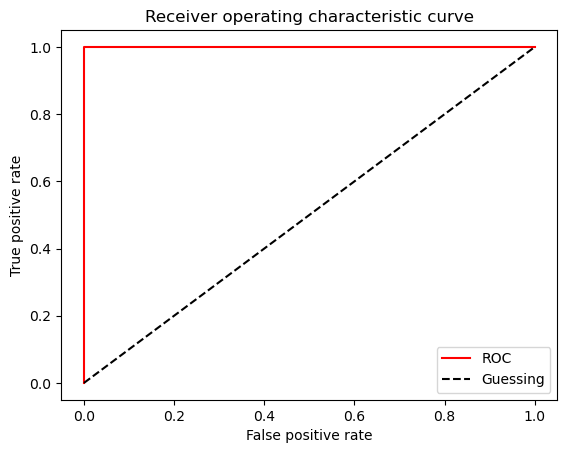

In [22]:
plot_roc_curve(fpr, tpr)

# Confusion matrix

In [23]:
from sklearn.metrics import confusion_matrix

In [31]:
y_preds = clf.predict(X_test)
np.shape(y_preds), np.shape(y_test)

((61,), (61,))

In [28]:
confusion_matrix(y_test, y_preds)

array([[24,  5],
       [ 5, 27]])

In [32]:
pd.crosstab(y_test, y_preds, rownames = ["Actual labels"], colnames=["Predicted labels"])

Predicted labels,0,1
Actual labels,,
0,24,5
1,5,27


# Import conda package into the current environment from a Jupyter Notebook

In [34]:
import sys
# Bang function
!conda install --yes --prefix {sys.prefix} seaborn

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 25.11.1
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c defaults conda




<Axes: >

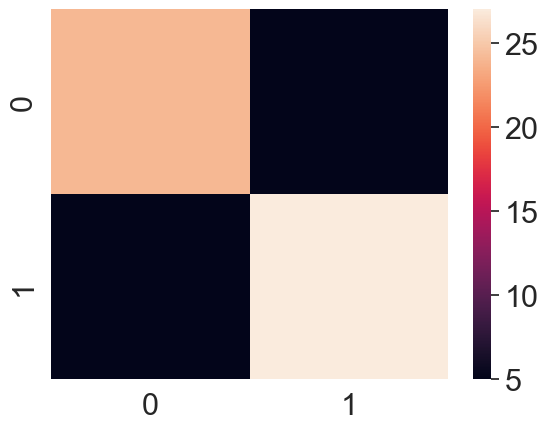

In [41]:
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_preds)

sns.set(font_scale = 2)
sns.heatmap(conf_matrix)

# New version 

In [42]:
import sklearn
sklearn.__version__

'1.6.1'

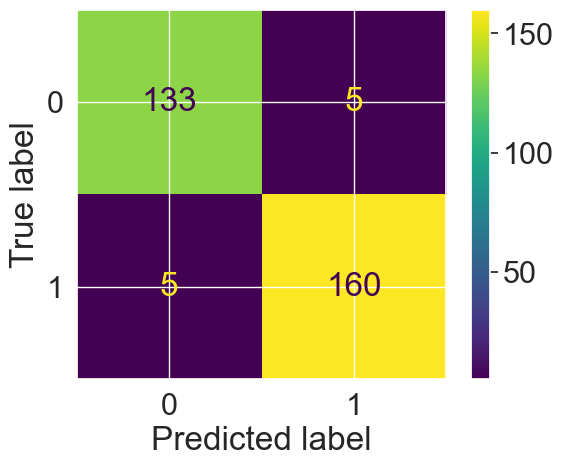

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(estimator = clf, X=X, y=y)

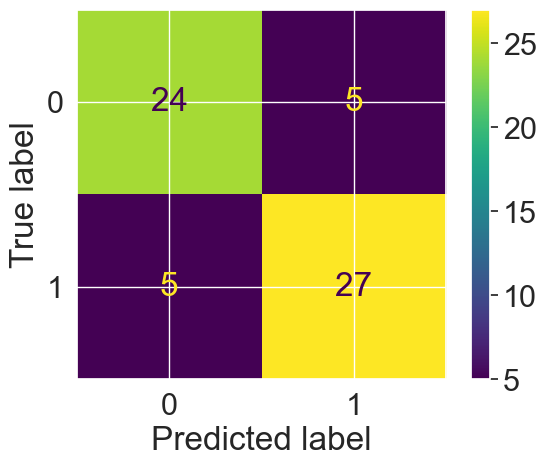

In [44]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_preds)

# Classification Report

In [46]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



### F1-score is calculated as the harmonic mean of precision and recall

In [ ]:
# f1-score = 2 * (recall * precision) / (recall + precision)

In [ ]:
# macro avg = f1-score + f1-score / (2)

In [ ]:
# weighed avg = f1-score * support + f1-score * support / (2)

In [49]:
y_test = np.zeros(10000)
y_test[0] = 1
y_test[:10]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [59]:
y_preds = np.zeros(10000)
pd.DataFrame(classification_report(y_true = y_test, y_pred = y_preds, output_dict=True, zero_division=0))

,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.99990,0.0,0.9999,0.499950,0.99980
recall,1.00000,0.0,0.9999,0.500000,0.99990
f1-score,0.99995,0.0,0.9999,0.499975,0.99985
support,9999.00000,1.0,0.9999,10000.000000,10000.00000
